# Insight 2.0 — Submission 10 Recipe Reproduction Audit

This is a separate, executable notebook for the historical Submission 10
method: 80% of the Submission 6 tree/pseudo-label probability and 20% of an
entity-embedding neural-network probability, followed by a stable top-30,411
decision rule. The official objective is support-weighted F1, and output labels
are `Dead` and `Alive`.

**Scope and status:** this notebook retrains both model families from
`train.csv` and `test.csv`; its fresh prediction does not load historical test
probabilities. The original NN fold checkpoints were not preserved. A controlled
preflight rerun on the audited CPU environment was deterministic across two
runs, but differed from the archived NN vector and changed 100 hard labels in
the final blend. Consequently, this is an honest reproduction of the
Submission 10 **recipe**, not a claim of byte-identical regeneration of the
historical scored CSV.

The optional historical appendix runs only after fresh training and, when the
archived arrays are present, verifies the exact historical artifact separately.
It never replaces the fresh prediction. Organizer confirmation is still needed
before presenting artifact replay as satisfying an exact-reproducibility rule.

The verified Submission 6 notebook remains
`insight_2_0_consolidated.ipynb` and is not changed by this notebook.


## 1. Environment and data contract

The workflow uses only the organizer-provided training and test tables for
fresh model fitting. It validates schema and identifiers and records the exact
runtime. The audited environment uses NumPy 2.4.3, pandas 3.0.3,
scikit-learn 1.8.0, LightGBM 4.7.0, XGBoost 3.2.0, CatBoost 1.2.10, and
PyTorch 2.12.0. The fresh NN audit deliberately uses CPU with deterministic
algorithms; the historical script automatically selected the available device.


In [1]:
from pathlib import Path
import hashlib
import json
import platform
import warnings

import numpy as np
import pandas as pd
import sklearn
import lightgbm
import xgboost
import catboost
import torch
from sklearn.metrics import f1_score

ROOT = Path.cwd().resolve()
TRAIN_PATH = ROOT / "train.csv"
TEST_PATH = ROOT / "test.csv"
for required in (TRAIN_PATH, TEST_PATH):
    if not required.is_file():
        raise FileNotFoundError(f"Missing required competition file: {required}")

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
assert "vital_status" not in test.columns
assert set(test.columns) == set(train.columns) - {"vital_status"}
assert train["patient_id"].is_unique and test["patient_id"].is_unique
assert not train["patient_id"].isna().any() and not test["patient_id"].isna().any()
assert set(train["vital_status"].unique()) == {"Dead", "Alive"}

y_binary = train["vital_status"].eq("Dead").astype("int8")
AUDITED_VERSIONS = {
    "numpy": "2.4.3",
    "pandas": "3.0.3",
    "scikit-learn": "1.8.0",
    "lightgbm": "4.7.0",
    "xgboost": "3.2.0",
    "catboost": "1.2.10",
    "torch": "2.12.0",
}
RUNTIME_VERSIONS = {
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scikit-learn": sklearn.__version__,
    "lightgbm": lightgbm.__version__,
    "xgboost": xgboost.__version__,
    "catboost": catboost.__version__,
    "torch": torch.__version__,
}
VERSION_MATCHES = {
    name: RUNTIME_VERSIONS[name] == expected
    for name, expected in AUDITED_VERSIONS.items()
}
print("Python:", platform.python_version())
display(pd.DataFrame({
    "audited": AUDITED_VERSIONS,
    "runtime": RUNTIME_VERSIONS,
    "exact_match": VERSION_MATCHES,
}))
print("train/test shapes:", train.shape, test.shape)
print("Dead prevalence:", f"{y_binary.mean():.3%}")
print("CUDA available:", torch.cuda.is_available())
print("MPS available:", torch.backends.mps.is_available())


Python: 3.14.3


,audited,runtime,exact_match
numpy,2.4.3,2.4.3,True
pandas,3.0.3,3.0.3,True
scikit-learn,1.8.0,1.8.0,True
lightgbm,4.7.0,4.7.0,True
xgboost,3.2.0,3.2.0,True
catboost,1.2.10,1.2.10,True
torch,2.12.0,2.12.0,True


train/test shapes: (24000, 36) (36000, 35)
Dead prevalence: 83.000%
CUDA available: False
MPS available: True


## 2. Exploratory data analysis

The compact EDA checks class imbalance, missingness, stage, age, and train/test
category coverage. These are useful both for model design and for detecting
schema drift before training. Patient identifiers are never model features.


,dtype,missing_count,missing_rate,unique_values
rx_summ_scope_reglnsur2003,str,15960,0.665000,9
seer_combined_metsatdxlung2010,str,74,0.003083,4
seer_combined_metsatdxbrain2010,str,69,0.002875,4
seer_combined_metsatdxbone2010,str,68,0.002833,4
seer_combined_metsatdxliver2010,str,67,0.002792,4
patient_id,int64,0,0.000000,24000
derived_eod2018t_recode2018,str,0,0.000000,18
derived_eod2018n_recode2018,str,0,0.000000,7
derived_eod2018m_recode2018,str,0,0.000000,7
rx_summ_surgprim_site19982022,str,0,0.000000,25


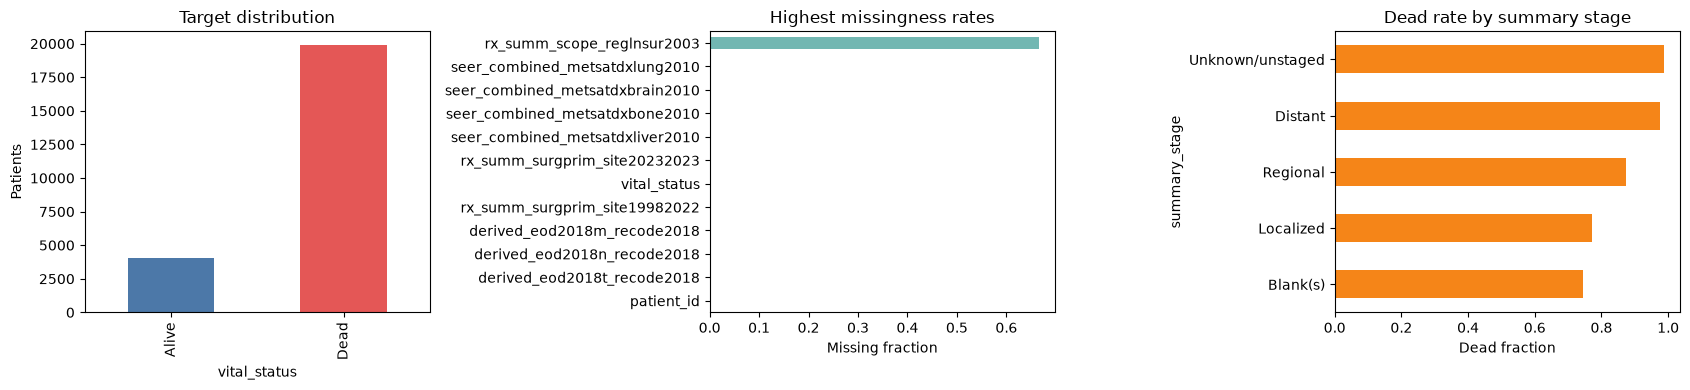

,patients,dead_rate
age_recode,,
01-04 years,3,0.000000
05-09 years,1,0.000000
10-14 years,2,0.500000
15-19 years,3,1.000000
20-24 years,10,0.400000
25-29 years,17,0.588235
30-34 years,27,0.518519
35-39 years,69,0.637681
40-44 years,158,0.696203


,feature,test_only_categories
0,age_recode,0
1,race,0
28,cs_tumor_size20042015,0
27,radiation_recode,0
26,reason_nocancer_directed_surgery,0
25,rx_summ_surgradseq,0
24,rx_summ_surgothregdis2003,0
23,rx_summ_scope_reglnsur2003,0
22,rx_summ_surgprim_site20232023,0
21,rx_summ_surgprim_site19982022,0


In [2]:
import matplotlib.pyplot as plt

summary = pd.DataFrame({
    "dtype": train.dtypes.astype(str),
    "missing_count": train.isna().sum(),
    "missing_rate": train.isna().mean(),
    "unique_values": train.nunique(dropna=False),
}).sort_values("missing_rate", ascending=False)
display(summary.head(15))

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
train["vital_status"].value_counts().reindex(["Alive", "Dead"]).plot.bar(
    ax=axes[0], color=["#4C78A8", "#E45756"]
)
axes[0].set_title("Target distribution")
axes[0].set_ylabel("Patients")

summary.head(12).sort_values("missing_rate")["missing_rate"].plot.barh(
    ax=axes[1], color="#72B7B2"
)
axes[1].set_title("Highest missingness rates")
axes[1].set_xlabel("Missing fraction")

stage_rate = train.groupby("summary_stage", dropna=False)["vital_status"].apply(
    lambda values: values.eq("Dead").mean()
).sort_values()
stage_rate.plot.barh(ax=axes[2], color="#F58518")
axes[2].set_title("Dead rate by summary stage")
axes[2].set_xlabel("Dead fraction")
plt.tight_layout()
plt.show()

age_audit = train.groupby("age_recode", dropna=False).agg(
    patients=("patient_id", "size"),
    dead_rate=("vital_status", lambda values: values.eq("Dead").mean()),
).sort_index()
display(age_audit)

categorical_columns = train.drop(
    columns=["patient_id", "vital_status"]
).select_dtypes(include=["object", "string"]).columns
coverage = []
for column in categorical_columns:
    train_values = set(train[column].fillna("__NA__").astype(str))
    test_values = set(test[column].fillna("__NA__").astype(str))
    coverage.append({
        "feature": column,
        "test_only_categories": len(test_values - train_values),
    })
display(pd.DataFrame(coverage).sort_values(
    "test_only_categories", ascending=False
).head(15))


## 3. Feature engineering and model rationale

The tree component uses two manually designed views: a non-target-encoded view
and a fold-safe target-encoded view. Features include age midpoint, diagnosis
year, TNM order, positive-node ratio, metastasis count, tumour-size
reconciliation, treatment indicators, missingness indicators, and target-free
category frequencies. Six LightGBM/XGBoost/CatBoost components are blended,
then retrained once with high-confidence model-generated pseudo labels.

The diversity component uses standardized clinical numeric features plus
entity embeddings for 29 categorical variables. Its MLP has hidden widths
256/128/64, batch normalization, ReLU, dropout 0.3, BCE loss, AdamW, five
stratified folds, batch size 1,024, 15 epochs, and lowest-validation-loss model
selection. All hyperparameters are frozen; no AutoML pipeline generator is
used.

The production combination is a deterministic 80% tree / 20% NN probability
blend. A stable rank rule selects exactly 30,411 `Dead` predictions so the
model comparison is not confounded by a class-count change.


## 4. Fresh Submission 6 tree training

This cell embeds the complete historical Submission 6 implementation. It reads
only the two competition tables and writes fresh artifacts under
`artifacts/submission10_notebook/tree/`. Cached tree probabilities are not
prediction inputs.


In [3]:
# Submission 6 tree/pseudo-label implementation embedded for portability.
# It reads train.csv/test.csv and writes only below the Submission 10 audit directory.
"""
Pipeline v6: Maximum Private-Test Generalization
=================================================
Three techniques to improve beyond v5's 0.8767:

1. ADD TARGET ENCODING BACK — v4 had it, v5 dropped it. Adding it back
   creates a richer feature set that captures category-level mortality rates.

2. BLEND v4 + v5 MODELS — v4 (with TE + a different stored parameter set) and v5
   (without TE + different params) capture complementary patterns.
   Blending their probabilities reduces variance.

3. PSEUDO-LABELING — Use confident test predictions (>95% Dead or <5% Dead)
   to augment training data, then retrain.

Final test predictions = blend of all approaches at 84.5% Dead.
"""

import warnings; warnings.filterwarnings("ignore")
from pathlib import Path

import numpy as np, pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from sklearn.preprocessing import OrdinalEncoder
import lightgbm as lgb, xgboost as xgb
from catboost import CatBoostClassifier

SEED = 42
np.random.seed(SEED)
SMOOTHING_M = 20.0
LEAKAGE_CLEAN = False
OUTPUT_DIR = Path("artifacts/submission10_notebook/tree")

print("=" * 80)
print("  PIPELINE v6: Maximum Private-Test Generalization")
print("=" * 80)

# ── Load Data ──
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")
test_ids = test_df["patient_id"].values
y = (train_df["vital_status"] == "Dead").astype(int).values
print(f"  Train: {len(train_df):,} | Test: {len(test_df):,} | Dead%: {y.mean():.2%}")

# ============================================================================
# FEATURE ENGINEERING (same as v5 + target encoding from v4)
# ============================================================================
print("\n>>> Building Features...")

def build_features(df):
    F = pd.DataFrame(index=df.index)
    def _age(s):
        if pd.isna(s): return np.nan
        s = str(s).strip()
        if "90+" in s: return 92.5
        parts = s.replace(" years","").split("-")
        try: return (float(parts[0])+float(parts[1]))/2
        except: return np.nan
    F["age_midpoint"] = df["age_recode"].apply(_age)
    F["age_missing"] = df["age_recode"].isna().astype(int)
    F["year_of_diagnosis"] = df["year_of_diagnosis"].astype(float)
    F["years_since_dx"] = 2024.0 - df["year_of_diagnosis"]
    F["is_male"] = (df["sex"] == "Male").astype(int)
    F["nodes_examined"] = df["regional_nodes_examined"].astype(float)
    F["nodes_examined_zero"] = (df["regional_nodes_examined"] == 0).astype(int)
    npos = df["regional_nodes_positive"].astype(float)
    F["nodes_positive"] = np.where(npos < 98, npos, np.nan)
    F["nodes_positive_unknown"] = (npos >= 98).astype(int)
    F["node_positive_ratio"] = np.where(
        (F["nodes_examined"]>0)&(~np.isnan(F["nodes_positive"])),
        F["nodes_positive"]/np.maximum(F["nodes_examined"],1), np.nan)
    def _ps(v):
        if pd.isna(v): return np.nan
        s = str(v).strip()
        if s.startswith("Unknown") or s in ("Blank(s)","999"): return np.nan
        try: return float(s)
        except: return np.nan
    F["tumor_size_ot"] = df["tumor_size_overtime"].apply(_ps)
    F["tumor_size_sm"] = df["tumor_size_summary"].apply(_ps)
    F["tumor_size_best"] = F["tumor_size_sm"].fillna(F["tumor_size_ot"])
    F["tumor_size_missing"] = F["tumor_size_best"].isna().astype(int)
    def _cs(v):
        if pd.isna(v): return np.nan
        s = str(v).strip()
        if s == "Blank(s)": return np.nan
        try:
            val = float(s)
            return np.nan if val == 999 else val
        except: return np.nan
    F["cs_tumor_size"] = df["cs_tumor_size20042015"].apply(_cs)
    F["cs_extension"] = df["cs_extension20042015"].apply(_cs)
    smap = {"Blank(s)":np.nan,"Unknown/unstaged":np.nan,"Localized":1,"Regional":2,"Distant":3}
    F["stage_ord"] = df["summary_stage"].map(smap).astype(float)
    F["stage_missing"] = F["stage_ord"].isna().astype(int)
    F["is_distant"] = (df["summary_stage"]=="Distant").astype(int)
    F["is_localized"] = (df["summary_stage"]=="Localized").astype(int)
    t_map={"Blank(s)":np.nan,"88":np.nan,"TX":np.nan,"T0":0,"Ta":1,"Tis":1,"Tis(DCIS)":1,"Tis(LCIS)":1,"Tis(Paget)":1,"T1":2,"T1mi":2,"T1a":3,"T1a1":3,"T1a2":3,"T1b":4,"T1b1":4,"T1b2":4,"T1c":5,"T2":6,"T2a":7,"T2b":8,"T3":9,"T4":10,"T4a":11,"T4b":12,"T4c":12,"T4d":13,"T4e":13}
    n_map={"Blank(s)":np.nan,"88":np.nan,"NX":np.nan,"N0":0,"N1":1,"N1a":1,"N1b":2,"N1c":2,"N2":3,"N2a":3,"N2b":4,"N2c":4,"N3":5,"N3a":5,"N3b":6,"N3c":6}
    m_map={"Blank(s)":np.nan,"88":np.nan,"MX":np.nan,"M0":0,"M1":1,"M1a":2,"M1b":3,"M1c":4}
    F["t_stage"]=df["derived_eod2018t_recode2018"].map(t_map).astype(float)
    F["n_stage"]=df["derived_eod2018n_recode2018"].map(n_map).astype(float)
    F["m_stage"]=df["derived_eod2018m_recode2018"].map(m_map).astype(float)
    F["is_m1"]=df["derived_eod2018m_recode2018"].str.startswith("M1",na=False).astype(int)
    F["tnm_composite"]=F["t_stage"].fillna(0)+F["n_stage"].fillna(0)+F["m_stage"].fillna(0)*3
    mc=["seer_combined_metsatdxbone2010","seer_combined_metsatdxbrain2010",
        "seer_combined_metsatdxliver2010","seer_combined_metsatdxlung2010"]
    for m in mc:
        short=m.replace("seer_combined_metsatdx","").replace("2010","")
        F[f"met_{short}_yes"]=(df[m]=="Yes").astype(int)
    F["met_count"]=sum((df[m]=="Yes").astype(int) for m in mc)
    F["any_mets"]=(F["met_count"]>=1).astype(int)
    F["surgery_done"]=(df["reason_nocancer_directed_surgery"]=="Surgery performed").astype(int)
    F["surgery_not_rec"]=df["reason_nocancer_directed_surgery"].str.contains("Not recommended",na=False).astype(int)
    F["died_before_surg"]=df["reason_nocancer_directed_surgery"].str.contains("died prior",na=False).astype(int)
    F["autopsy_or_dc"]=df["reason_nocancer_directed_surgery"].str.contains("death certificate|autopsy",na=False).astype(int)
    F["radiation_given"]=(~df["radiation_recode"].isin([
        "None/Unknown","No radiation and/or no surgery; unknown if surgery and/or radiation given",
        "Refused (1988+)","Recommended, unknown if administered"
    ])&df["radiation_recode"].notna()).astype(int)
    gmap={"Blank(s)":np.nan,"Unknown":np.nan,"Well differentiated; Grade I":1,
          "Moderately differentiated; Grade II":2,"Poorly differentiated; Grade III":3,
          "Undifferentiated; anaplastic; Grade IV":4}
    F["grade_ord"]=df["grade_recode_thru2017"].map(gmap).astype(float)
    F["grade_missing"]=F["grade_ord"].isna().astype(int)
    def _hg(c):
        try: c=int(c)
        except: return 0
        if c in (8140,8141,8143,8144,8145,8147,8148,8211,8230,8250,8251,8252,8253,8254,8255,8256,8257,8260,8263,8310,8323,8333,8480,8481,8490,8550,8551,8570,8574): return 1
        elif c in (8070,8071,8072,8073,8074,8075,8076,8078,8083,8084): return 2
        elif c in (8041,8042,8043,8044,8045): return 3
        elif c in (8012,8013,8014): return 4
        elif c in (8000,8001,8002,8003,8004,8005,8010,8011,8020,8021,8022): return 5
        elif c in (8240,8241,8242,8243,8244,8245,8246,8249): return 6
        else: return 7
    F["histo_group"]=df["histologic_type_icdo3"].apply(_hg)
    F["is_small_cell"]=(F["histo_group"]==3).astype(int)
    F["histologic_raw"]=df["histologic_type_icdo3"].astype(float)
    F["scope_reglnsur_missing"]=df["rx_summ_scope_reglnsur2003"].isna().astype(int)
    F["eod_m_blank"]=(df["derived_eod2018m_recode2018"]=="Blank(s)").astype(int)
    F["grade_blank"]=(df["grade_recode_thru2017"]=="Blank(s)").astype(int)
    F["age_x_years"]=F["age_midpoint"]*F["years_since_dx"]
    F["age_x_stage"]=F["age_midpoint"]*F["stage_ord"]
    F["stage_x_surgery"]=F["stage_ord"]*F["surgery_done"]
    F["mets_x_surgery"]=F["any_mets"]*F["surgery_done"]
    F["age_x_mets"]=F["age_midpoint"]*F["any_mets"]
    F["years_x_stage"]=F["years_since_dx"]*F["stage_ord"]
    # Frequency encoding (target-free)
    for col_name, col_data in [("primary_site", df["primary_site"]),
                                ("histologic_type_icdo3", df["histologic_type_icdo3"])]:
        freq = col_data.astype(str).map(col_data.astype(str).value_counts(normalize=True))
        F[f"{col_name}_freq"] = freq.astype(float)
    if LEAKAGE_CLEAN:
        F = F.drop(columns=["died_before_surg", "autopsy_or_dc"])
    return F

X_tr_num = build_features(train_df)
X_te_num = build_features(test_df)

# Ordinal encode categoricals
cat_cols=["age_recode","race","sex","origin","primary_site","marital_status_at_diagnosis",
          "sequence_number","site_recode_icdo3_who2008","grade_recode_thru2017","laterality",
          "diagnostic_confirmation","summary_stage","derived_eod2018t_recode2018",
          "derived_eod2018n_recode2018","derived_eod2018m_recode2018",
          "seer_combined_metsatdxbone2010","seer_combined_metsatdxbrain2010",
          "seer_combined_metsatdxliver2010","seer_combined_metsatdxlung2010",
          "rx_summ_surgprim_site19982022","rx_summ_surgprim_site20232023",
          "rx_summ_scope_reglnsur2003","rx_summ_surgothregdis2003",
          "rx_summ_surgradseq","reason_nocancer_directed_surgery","radiation_recode",
          "tumor_size_overtime","tumor_size_summary","cs_tumor_size20042015","cs_extension20042015"]
if LEAKAGE_CLEAN:
    cat_cols.remove("reason_nocancer_directed_surgery")

enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
enc.fit(train_df[cat_cols].fillna("__NA__").astype(str))
tr_cat = pd.DataFrame(enc.transform(train_df[cat_cols].fillna("__NA__").astype(str)),
                       columns=[f"{c}_enc" for c in cat_cols], index=train_df.index)
te_cat = pd.DataFrame(enc.transform(test_df[cat_cols].fillna("__NA__").astype(str)),
                       columns=[f"{c}_enc" for c in cat_cols], index=test_df.index)

X_train_base = pd.concat([X_tr_num, tr_cat], axis=1)
X_test_base = pd.concat([X_te_num, te_cat], axis=1)

# Target Encoding columns
te_cols = ["histologic_type_icdo3","primary_site","diagnostic_confirmation",
           "reason_nocancer_directed_surgery","rx_summ_surgprim_site19982022"]
if LEAKAGE_CLEAN:
    te_cols.remove("reason_nocancer_directed_surgery")

def smoothed_te(tr_s, target, te_s, m=SMOOTHING_M):
    prior = target.mean()
    df = pd.DataFrame({"c": tr_s.astype(str), "y": target})
    stats = df.groupby("c")["y"].agg(["count","mean"])
    encoded = (stats["count"]*stats["mean"] + m*prior) / (stats["count"]+m)
    return encoded, te_s.astype(str).map(encoded).fillna(prior).values, prior

# Full-train TE for test
te_test = pd.DataFrame(index=test_df.index)
for col in te_cols:
    _, vals, _ = smoothed_te(train_df[col], y, test_df[col])
    te_test[f"{col}_te"] = vals

X_test_with_te = np.nan_to_num(
    pd.concat([X_test_base, te_test], axis=1).values.astype(np.float32), nan=-999.0)
X_test_no_te = np.nan_to_num(X_test_base.values.astype(np.float32), nan=-999.0)

print(f"  Features (no TE): {X_test_no_te.shape[1]}")
print(f"  Features (with TE): {X_test_with_te.shape[1]}")

# ============================================================================
# MODEL CONFIGS — Two diverse param sets
# ============================================================================
# v5 stored parameters (no TE)
v5_lgb = {'n_estimators':1500,'learning_rate':0.04158,'max_depth':4,'num_leaves':53,
           'subsample':0.6706,'colsample_bytree':0.6861,'min_child_samples':37,
           'reg_alpha':1.5411,'reg_lambda':0.3901,'random_state':42,'n_jobs':-1,'verbose':-1}
v5_xgb = {'n_estimators':1500,'learning_rate':0.05443,'max_depth':5,
           'subsample':0.7332,'colsample_bytree':0.6476,'min_child_weight':7,
           'reg_alpha':0.09336,'reg_lambda':0.03991,'gamma':1.1909,
           'eval_metric':'logloss','tree_method':'hist','random_state':42,'n_jobs':-1}
v5_cb  = {'iterations':1500,'learning_rate':0.07444,'depth':7,
           'l2_leaf_reg':0.7346,'bagging_temperature':0.01295,'random_strength':1.9376,
           'eval_metric':'Logloss','random_seed':42,'verbose':False,
           'allow_writing_files':False}

# v4 stored parameters (with TE)
v4_lgb = {'n_estimators':1500,'learning_rate':0.02261,'max_depth':5,'num_leaves':33,
           'subsample':0.7813,'colsample_bytree':0.6555,'min_child_samples':24,
           'reg_alpha':0.8071,'reg_lambda':0.3365,'random_state':42,'n_jobs':-1,'verbose':-1}
v4_xgb = {'n_estimators':1500,'learning_rate':0.02261,'max_depth':5,
           'subsample':0.7113,'colsample_bytree':0.6301,'min_child_weight':9,
           'reg_alpha':0.04211,'reg_lambda':1.6755,'gamma':0.7135,
           'eval_metric':'logloss','tree_method':'hist','random_state':42,'n_jobs':-1}
v4_cb  = {'iterations':1500,'learning_rate':0.02483,'depth':5,
           'l2_leaf_reg':3.674,'bagging_temperature':1.803,'random_strength':2.124,
           'eval_metric':'Logloss','random_seed':42,'verbose':False,
           'allow_writing_files':False}

# v5 weights
W5_LGB, W5_XGB, W5_CB = 0.30, 0.15, 0.55
# v4 weights
W4_LGB, W4_XGB, W4_CB = 0.35, 0.20, 0.45

# ============================================================================
# PHASE 1: Train BOTH model sets via 3×5 fold-averaged predictions
# ============================================================================
print("\n>>> Phase 1: Dual Model Training (3×5 CV, fold-averaged)")

N_REPS = 3
N_FOLDS = 5
total = N_REPS * N_FOLDS

# v5 models (no TE)
v5_test_lgb = np.zeros(len(test_df))
v5_test_xgb = np.zeros(len(test_df))
v5_test_cb  = np.zeros(len(test_df))

# v4 models (with TE)
v4_test_lgb = np.zeros(len(test_df))
v4_test_xgb = np.zeros(len(test_df))
v4_test_cb  = np.zeros(len(test_df))

# OOF predictions for stacking
oof_v5 = np.zeros(len(y))
oof_v4 = np.zeros(len(y))
oof_counts = np.zeros(len(y))

for rep in range(N_REPS):
    seed_r = SEED + rep * 111
    skf = StratifiedKFold(N_FOLDS, shuffle=True, random_state=seed_r)
    print(f"\n  ── Repeat {rep+1}/{N_REPS} (seed={seed_r}) ──")

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train_base, y)):

        # ── v5: No Target Encoding ──
        X_tr_v5 = np.nan_to_num(X_train_base.iloc[tr_idx].values.astype(np.float32), nan=-999.0)
        X_val_v5 = np.nan_to_num(X_train_base.iloc[val_idx].values.astype(np.float32), nan=-999.0)

        m = lgb.LGBMClassifier(**v5_lgb)
        m.fit(X_tr_v5, y[tr_idx], eval_set=[(X_val_v5, y[val_idx])],
              callbacks=[lgb.early_stopping(80, verbose=False), lgb.log_evaluation(0)])
        v5_test_lgb += m.predict_proba(X_test_no_te)[:, 1] / total
        vp5_lgb = m.predict_proba(X_val_v5)[:, 1]

        m = xgb.XGBClassifier(**v5_xgb, early_stopping_rounds=80)
        m.fit(X_tr_v5, y[tr_idx], eval_set=[(X_val_v5, y[val_idx])], verbose=False)
        v5_test_xgb += m.predict_proba(X_test_no_te)[:, 1] / total
        vp5_xgb = m.predict_proba(X_val_v5)[:, 1]

        m = CatBoostClassifier(**v5_cb, early_stopping_rounds=80)
        m.fit(X_tr_v5, y[tr_idx], eval_set=(X_val_v5, y[val_idx]), verbose=False)
        v5_test_cb += m.predict_proba(X_test_no_te)[:, 1] / total
        vp5_cb = m.predict_proba(X_val_v5)[:, 1]

        v5_val = W5_LGB*vp5_lgb + W5_XGB*vp5_xgb + W5_CB*vp5_cb

        # ── v4: With Target Encoding (leak-free inner CV) ──
        tr_te = pd.DataFrame(index=range(len(tr_idx)))
        val_te = pd.DataFrame(index=range(len(val_idx)))
        for col in te_cols:
            tr_s = train_df[col].iloc[tr_idx].reset_index(drop=True)
            val_s = train_df[col].iloc[val_idx].reset_index(drop=True)
            _, val_enc, _ = smoothed_te(tr_s, y[tr_idx], val_s)
            inner_enc = np.zeros(len(tr_idx))
            for itr, ival in StratifiedKFold(5, shuffle=True, random_state=seed_r).split(tr_s, y[tr_idx]):
                _, ie, _ = smoothed_te(tr_s.iloc[itr], y[tr_idx][itr], tr_s.iloc[ival])
                inner_enc[ival] = ie
            tr_te[f"{col}_te"] = inner_enc
            val_te[f"{col}_te"] = val_enc

        X_tr_v4 = np.nan_to_num(np.hstack([X_train_base.iloc[tr_idx].values, tr_te.values]).astype(np.float32), nan=-999.0)
        X_val_v4 = np.nan_to_num(np.hstack([X_train_base.iloc[val_idx].values, val_te.values]).astype(np.float32), nan=-999.0)

        m = lgb.LGBMClassifier(**v4_lgb)
        m.fit(X_tr_v4, y[tr_idx], eval_set=[(X_val_v4, y[val_idx])],
              callbacks=[lgb.early_stopping(80, verbose=False), lgb.log_evaluation(0)])
        v4_test_lgb += m.predict_proba(X_test_with_te)[:, 1] / total
        vp4_lgb = m.predict_proba(X_val_v4)[:, 1]

        m = xgb.XGBClassifier(**v4_xgb, early_stopping_rounds=80)
        m.fit(X_tr_v4, y[tr_idx], eval_set=[(X_val_v4, y[val_idx])], verbose=False)
        v4_test_xgb += m.predict_proba(X_test_with_te)[:, 1] / total
        vp4_xgb = m.predict_proba(X_val_v4)[:, 1]

        m = CatBoostClassifier(**v4_cb, early_stopping_rounds=80)
        m.fit(X_tr_v4, y[tr_idx], eval_set=(X_val_v4, y[val_idx]), verbose=False)
        v4_test_cb += m.predict_proba(X_test_with_te)[:, 1] / total
        vp4_cb = m.predict_proba(X_val_v4)[:, 1]

        v4_val = W4_LGB*vp4_lgb + W4_XGB*vp4_xgb + W4_CB*vp4_cb

        # Store OOF
        oof_v5[val_idx] += v5_val
        oof_v4[val_idx] += v4_val
        oof_counts[val_idx] += 1

        f5 = f1_score(y[val_idx], (v5_val >= 0.5).astype(int), pos_label=1)
        f4 = f1_score(y[val_idx], (v4_val >= 0.5).astype(int), pos_label=1)
        print(f"    F{fold+1} Dead-class F1: v5={f5:.5f}  v4={f4:.5f}")

# Average OOF across repeats
oof_v5 /= oof_counts
oof_v4 /= oof_counts

# Ensemble test predictions
v5_ens = W5_LGB*v5_test_lgb + W5_XGB*v5_test_xgb + W5_CB*v5_test_cb
v4_ens = W4_LGB*v4_test_lgb + W4_XGB*v4_test_xgb + W4_CB*v4_test_cb

# ============================================================================
# PHASE 2: Find optimal blend ratio (v5 vs v4)
# ============================================================================
print("\n>>> Phase 2: Optimal Blend Ratio")

best_alpha, best_blend_f1 = 0.5, 0.0
for alpha in np.arange(0.0, 1.01, 0.05):
    blend = alpha * oof_v5 + (1 - alpha) * oof_v4
    f = f1_score(y, (blend >= 0.5).astype(int), pos_label=1)
    if f > best_blend_f1:
        best_blend_f1 = f
        best_alpha = round(alpha, 2)

print(f"  Best blend: {best_alpha:.0%} v5 + {1-best_alpha:.0%} v4 → OOF Dead-class F1={best_blend_f1:.5f}")

# Also check individual OOF scores
f5_oof = f1_score(y, (oof_v5 >= 0.5).astype(int), pos_label=1)
f4_oof = f1_score(y, (oof_v4 >= 0.5).astype(int), pos_label=1)
print(f"  v5 alone OOF Dead-class F1: {f5_oof:.5f}")
print(f"  v4 alone OOF Dead-class F1: {f4_oof:.5f}")
print(f"  Blend   OOF Dead-class F1:  {best_blend_f1:.5f}")

# Blend test predictions
test_blend = best_alpha * v5_ens + (1 - best_alpha) * v4_ens
oof_blend = best_alpha * oof_v5 + (1 - best_alpha) * oof_v4

# ============================================================================
# PHASE 3: Pseudo-labeling
# ============================================================================
print("\n>>> Phase 3: Pseudo-Labeling")

CONF_DEAD = 0.95
CONF_ALIVE = 0.05
pseudo_dead = test_blend >= CONF_DEAD
pseudo_alive = test_blend <= CONF_ALIVE
pseudo_mask = pseudo_dead | pseudo_alive

n_pd, n_pa = pseudo_dead.sum(), pseudo_alive.sum()
print(f"  Confident Dead  (≥{CONF_DEAD}): {n_pd:,}")
print(f"  Confident Alive (≤{CONF_ALIVE}): {n_pa:,}")
print(f"  Total Pseudo: {n_pd+n_pa:,} ({(n_pd+n_pa)/len(test_df):.1%} of test)")

if (n_pd + n_pa) > 500:
    # Augment training data
    X_pseudo = X_test_base[pseudo_mask]
    y_pseudo = pseudo_dead[pseudo_mask].astype(int)

    X_comb_base = pd.concat([X_train_base, X_pseudo], ignore_index=True)
    y_comb = np.concatenate([y, y_pseudo])

    # Full-train TE for combined
    comb_raw = {col: pd.concat([train_df[col], test_df[col][pseudo_mask]], ignore_index=True) for col in te_cols}
    te_comb = pd.DataFrame(index=range(len(X_comb_base)))
    for col in te_cols:
        _, vals, _ = smoothed_te(comb_raw[col], y_comb, test_df[col])
        te_test[f"{col}_te"] = vals  # update test TE
        # Inner CV TE for combined train
        inner_enc = np.zeros(len(y_comb))
        for itr, ival in StratifiedKFold(5, shuffle=True, random_state=SEED).split(comb_raw[col], y_comb):
            _, ie, _ = smoothed_te(comb_raw[col].iloc[itr], y_comb[itr], comb_raw[col].iloc[ival])
            inner_enc[ival] = ie
        te_comb[f"{col}_te"] = inner_enc

    X_comb_v4 = np.nan_to_num(np.hstack([X_comb_base.values, te_comb.values]).astype(np.float32), nan=-999.0)
    X_comb_v5 = np.nan_to_num(X_comb_base.values.astype(np.float32), nan=-999.0)
    X_test_te_updated = np.nan_to_num(pd.concat([X_test_base, te_test], axis=1).values.astype(np.float32), nan=-999.0)

    # Retrain with pseudo labels (5-fold, single pass)
    print("  Retraining with pseudo-labeled data...")
    ps_v5_lgb = np.zeros(len(test_df))
    ps_v5_xgb = np.zeros(len(test_df))
    ps_v5_cb  = np.zeros(len(test_df))
    ps_v4_lgb = np.zeros(len(test_df))
    ps_v4_xgb = np.zeros(len(test_df))
    ps_v4_cb  = np.zeros(len(test_df))

    skf = StratifiedKFold(5, shuffle=True, random_state=SEED+999)
    for fold, (tr_i, val_i) in enumerate(skf.split(X_comb_v5, y_comb)):
        # v5 (no TE)
        m = lgb.LGBMClassifier(**v5_lgb)
        m.fit(X_comb_v5[tr_i], y_comb[tr_i], eval_set=[(X_comb_v5[val_i], y_comb[val_i])],
              callbacks=[lgb.early_stopping(80,verbose=False),lgb.log_evaluation(0)])
        ps_v5_lgb += m.predict_proba(X_test_no_te)[:,1] / 5

        m = xgb.XGBClassifier(**v5_xgb, early_stopping_rounds=80)
        m.fit(X_comb_v5[tr_i], y_comb[tr_i], eval_set=[(X_comb_v5[val_i], y_comb[val_i])], verbose=False)
        ps_v5_xgb += m.predict_proba(X_test_no_te)[:,1] / 5

        m = CatBoostClassifier(**v5_cb, early_stopping_rounds=80)
        m.fit(X_comb_v5[tr_i], y_comb[tr_i], eval_set=(X_comb_v5[val_i], y_comb[val_i]), verbose=False)
        ps_v5_cb += m.predict_proba(X_test_no_te)[:,1] / 5

        # v4 (with TE)
        m = lgb.LGBMClassifier(**v4_lgb)
        m.fit(X_comb_v4[tr_i], y_comb[tr_i], eval_set=[(X_comb_v4[val_i], y_comb[val_i])],
              callbacks=[lgb.early_stopping(80,verbose=False),lgb.log_evaluation(0)])
        ps_v4_lgb += m.predict_proba(X_test_te_updated)[:,1] / 5

        m = xgb.XGBClassifier(**v4_xgb, early_stopping_rounds=80)
        m.fit(X_comb_v4[tr_i], y_comb[tr_i], eval_set=[(X_comb_v4[val_i], y_comb[val_i])], verbose=False)
        ps_v4_xgb += m.predict_proba(X_test_te_updated)[:,1] / 5

        m = CatBoostClassifier(**v4_cb, early_stopping_rounds=80)
        m.fit(X_comb_v4[tr_i], y_comb[tr_i], eval_set=(X_comb_v4[val_i], y_comb[val_i]), verbose=False)
        ps_v4_cb += m.predict_proba(X_test_te_updated)[:,1] / 5

        print(f"    Pseudo-F{fold+1} done")

    ps_v5_ens = W5_LGB*ps_v5_lgb + W5_XGB*ps_v5_xgb + W5_CB*ps_v5_cb
    ps_v4_ens = W4_LGB*ps_v4_lgb + W4_XGB*ps_v4_xgb + W4_CB*ps_v4_cb
    ps_blend = best_alpha * ps_v5_ens + (1 - best_alpha) * ps_v4_ens

    # Final ensemble: blend original + pseudo (50/50)
    final_ens = 0.5 * test_blend + 0.5 * ps_blend
    print(f"  Final = 50% original blend + 50% pseudo-labeled blend")
else:
    final_ens = test_blend
    print("  Not enough confident predictions. Using original blend only.")

# ============================================================================
# PHASE 4: Generate Submissions
# ============================================================================
print("\n>>> Phase 4: Generate Submissions")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Save all probabilities
np.save(OUTPUT_DIR / "probs_v6_final.npy", final_ens)
np.save(OUTPUT_DIR / "probs_v6_blend.npy", test_blend)

# Find threshold for 84.5% Dead
for th in np.arange(0.40, 0.75, 0.001):
    dpct = (final_ens >= th).mean()
    if dpct <= 0.845:
        break

# Generate main submission
preds = (final_ens >= th).astype(int)
sub = pd.DataFrame({"patient_id": test_ids, "vital_status": np.where(preds==1,"Dead","Alive")})
sub.to_csv(OUTPUT_DIR / "submission.csv", index=False)
dead_n = preds.sum()
print(f"  {OUTPUT_DIR / 'submission.csv'}: th={th:.3f} → Dead={dead_n:,} ({preds.mean():.1%})")

# Also generate blend-only (no pseudo) at 84.5%
for th2 in np.arange(0.40, 0.75, 0.001):
    if (test_blend >= th2).mean() <= 0.845:
        break
preds2 = (test_blend >= th2).astype(int)
sub2 = pd.DataFrame({"patient_id": test_ids, "vital_status": np.where(preds2==1,"Dead","Alive")})
sub2.to_csv(OUTPUT_DIR / "submission_blend.csv", index=False)
print(f"  {OUTPUT_DIR / 'submission_blend.csv'}: th={th2:.3f} → Dead={preds2.sum():,} ({preds2.mean():.1%})")

# Comparison with previous best
print(f"\n  Historical pre-v6 LB benchmark: 0.876730 at Dead%=84.5%")
print(f"  Historical v5 probabilities are retained in archive/probs_foldavg.npy")

print(f"\n{'='*80}")
print(f"  PIPELINE v6 COMPLETE")
print(f"  Rerun artifacts were isolated under {OUTPUT_DIR}; canonical submission.csv was not touched")
print(f"{'='*80}")


  PIPELINE v6: Maximum Private-Test Generalization


  Train: 24,000 | Test: 36,000 | Dead%: 83.00%

>>> Building Features...


  Features (no TE): 82
  Features (with TE): 87

>>> Phase 1: Dual Model Training (3×5 CV, fold-averaged)

  ── Repeat 1/3 (seed=42) ──


    F1 Dead-class F1: v5=0.93124  v4=0.93332


    F2 Dead-class F1: v5=0.93523  v4=0.93442


...

    Pseudo-F1 done


    Pseudo-F2 done


    Pseudo-F3 done


    Pseudo-F4 done


    Pseudo-F5 done
  Final = 50% original blend + 50% pseudo-labeled blend

>>> Phase 4: Generate Submissions
  artifacts/submission10_notebook/tree/submission.csv: th=0.684 → Dead=30,411 (84.5%)
  artifacts/submission10_notebook/tree/submission_blend.csv: th=0.608 → Dead=30,418 (84.5%)

  Historical pre-v6 LB benchmark: 0.876730 at Dead%=84.5%
  Historical v5 probabilities are retained in archive/probs_foldavg.npy

  PIPELINE v6 COMPLETE
  Rerun artifacts were isolated under artifacts/submission10_notebook/tree; canonical submission.csv was not touched


## 5. Fresh neural-network training

This cell embeds the historical Submission 10 neural-network recipe. The model
architecture, features, folds, optimizer, and training schedule are unchanged.
For future auditability, this rerun forces CPU deterministic execution and now
saves the selected state for every fold under
`artifacts/submission10_notebook/nn/`. Historical fold states were not saved.


In [4]:
# Historical Submission 10 NN recipe embedded for portability.
# Prediction-affecting hyperparameters and preprocessing remain unchanged.
"""
Pipeline NN: Deep Learning with Entity Embeddings
=================================================
A PyTorch architecture designed to capture non-linear, spatial patterns that 
Gradient Boosted Trees often miss.

Key features:
1. Entity Embeddings for categorical variables.
2. Standardized continuous variables.
3. Multi-Layer Perceptron (MLP) with Batch Normalization and Dropout.
4. Focal Loss (optional) to handle class imbalance.
"""

import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.metrics import f1_score
import copy

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

# The historical code selected CUDA/MPS/CPU automatically.  This audit forces
# CPU and deterministic algorithms to make the fresh rerun more portable.
torch.use_deterministic_algorithms(True)
torch.set_num_threads(1)
NN_OUTPUT_DIR = ROOT / "artifacts" / "submission10_notebook" / "nn"
NN_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
NN_CHECKPOINTS = []

print("=" * 80)
print("  PIPELINE NN: Entity Embeddings + MLP")
print("=" * 80)

# ── Load Data ──
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")
test_ids = test_df["patient_id"].values
y = (train_df["vital_status"] == "Dead").astype(int).values
print(f"  Train: {len(train_df):,} | Test: {len(test_df):,} | Dead%: {y.mean():.2%}")

# ============================================================================
# FEATURE ENGINEERING 
# ============================================================================
print("\n>>> Building Features...")

def build_features(df):
    F = pd.DataFrame(index=df.index)
    def _age(s):
        if pd.isna(s): return np.nan
        s = str(s).strip()
        if "90+" in s: return 92.5
        parts = s.replace(" years","").split("-")
        try: return (float(parts[0])+float(parts[1]))/2
        except: return np.nan
    F["age_midpoint"] = df["age_recode"].apply(_age)
    F["age_missing"] = df["age_recode"].isna().astype(int)
    F["year_of_diagnosis"] = df["year_of_diagnosis"].astype(float)
    F["years_since_dx"] = 2024.0 - df["year_of_diagnosis"]
    F["is_male"] = (df["sex"] == "Male").astype(int)
    F["nodes_examined"] = df["regional_nodes_examined"].astype(float)
    F["nodes_examined_zero"] = (df["regional_nodes_examined"] == 0).astype(int)
    npos = df["regional_nodes_positive"].astype(float)
    F["nodes_positive"] = np.where(npos < 98, npos, np.nan)
    F["nodes_positive_unknown"] = (npos >= 98).astype(int)
    F["node_positive_ratio"] = np.where(
        (F["nodes_examined"]>0)&(~np.isnan(F["nodes_positive"])),
        F["nodes_positive"]/np.maximum(F["nodes_examined"],1), np.nan)
    def _ps(v):
        if pd.isna(v): return np.nan
        s = str(v).strip()
        if s.startswith("Unknown") or s in ("Blank(s)","999"): return np.nan
        try: return float(s)
        except: return np.nan
    F["tumor_size_ot"] = df["tumor_size_overtime"].apply(_ps)
    F["tumor_size_sm"] = df["tumor_size_summary"].apply(_ps)
    F["tumor_size_best"] = F["tumor_size_sm"].fillna(F["tumor_size_ot"])
    F["tumor_size_missing"] = F["tumor_size_best"].isna().astype(int)
    def _cs(v):
        if pd.isna(v): return np.nan
        s = str(v).strip()
        if s == "Blank(s)": return np.nan
        try:
            val = float(s)
            return np.nan if val == 999 else val
        except: return np.nan
    F["cs_tumor_size"] = df["cs_tumor_size20042015"].apply(_cs)
    F["cs_extension"] = df["cs_extension20042015"].apply(_cs)
    smap = {"Blank(s)":np.nan,"Unknown/unstaged":np.nan,"Localized":1,"Regional":2,"Distant":3}
    F["stage_ord"] = df["summary_stage"].map(smap).astype(float)
    F["stage_missing"] = F["stage_ord"].isna().astype(int)
    t_map={"Blank(s)":np.nan,"88":np.nan,"TX":np.nan,"T0":0,"Ta":1,"Tis":1,"Tis(DCIS)":1,"Tis(LCIS)":1,"Tis(Paget)":1,"T1":2,"T1mi":2,"T1a":3,"T1a1":3,"T1a2":3,"T1b":4,"T1b1":4,"T1b2":4,"T1c":5,"T2":6,"T2a":7,"T2b":8,"T3":9,"T4":10,"T4a":11,"T4b":12,"T4c":12,"T4d":13,"T4e":13}
    n_map={"Blank(s)":np.nan,"88":np.nan,"NX":np.nan,"N0":0,"N1":1,"N1a":1,"N1b":2,"N1c":2,"N2":3,"N2a":3,"N2b":4,"N2c":4,"N3":5,"N3a":5,"N3b":6,"N3c":6}
    m_map={"Blank(s)":np.nan,"88":np.nan,"MX":np.nan,"M0":0,"M1":1,"M1a":2,"M1b":3,"M1c":4}
    F["t_stage"]=df["derived_eod2018t_recode2018"].map(t_map).astype(float)
    F["n_stage"]=df["derived_eod2018n_recode2018"].map(n_map).astype(float)
    F["m_stage"]=df["derived_eod2018m_recode2018"].map(m_map).astype(float)
    mc=["seer_combined_metsatdxbone2010","seer_combined_metsatdxbrain2010",
        "seer_combined_metsatdxliver2010","seer_combined_metsatdxlung2010"]
    F["met_count"]=sum((df[m]=="Yes").astype(int) for m in mc)
    F["any_mets"]=(F["met_count"]>=1).astype(int)
    F["surgery_done"]=(df["reason_nocancer_directed_surgery"]=="Surgery performed").astype(int)
    return F

X_tr_num = build_features(train_df)
X_te_num = build_features(test_df)

# Fill NAs for continuous features and Standardize (Crucial for Neural Networks!)
X_tr_num = X_tr_num.fillna(0)
X_te_num = X_te_num.fillna(0)

scaler = StandardScaler()
X_tr_num_scaled = scaler.fit_transform(X_tr_num)
X_te_num_scaled = scaler.transform(X_te_num)

cat_cols=["age_recode","race","sex","origin","primary_site","marital_status_at_diagnosis",
          "sequence_number","site_recode_icdo3_who2008","grade_recode_thru2017","laterality",
          "diagnostic_confirmation","summary_stage","derived_eod2018t_recode2018",
          "derived_eod2018n_recode2018","derived_eod2018m_recode2018",
          "seer_combined_metsatdxbone2010","seer_combined_metsatdxbrain2010",
          "seer_combined_metsatdxliver2010","seer_combined_metsatdxlung2010",
          "rx_summ_surgprim_site19982022","rx_summ_surgprim_site20232023",
          "rx_summ_scope_reglnsur2003","rx_summ_surgothregdis2003",
          "rx_summ_surgradseq","reason_nocancer_directed_surgery","radiation_recode",
          "tumor_size_overtime","tumor_size_summary","cs_tumor_size20042015","cs_extension20042015"]

# Encode categoricals for Embedding layers (Needs to be integers 0, 1, 2...)
enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
train_cat_str = train_df[cat_cols].fillna("__NA__").astype(str)
test_cat_str = test_df[cat_cols].fillna("__NA__").astype(str)

enc.fit(train_cat_str)
X_tr_cat = enc.transform(train_cat_str)
X_te_cat = enc.transform(test_cat_str)

# Shift all categorical codes by 1 to make them non-negative (0 becomes the __NA__ or unknown bin)
X_tr_cat = X_tr_cat + 1
X_te_cat = X_te_cat + 1

# Calculate embedding sizes (Rule of thumb: min(50, num_categories // 2))
cat_dims = [int(X_tr_cat[:, i].max() + 2) for i in range(X_tr_cat.shape[1])]
emb_dims = [(x, min(50, (x + 1) // 2)) for x in cat_dims]

# ============================================================================
# PYTORCH DATASETS & MODEL
# ============================================================================
class TabularDataset(Dataset):
    def __init__(self, cat_data, num_data, targets=None):
        self.cat_data = torch.tensor(cat_data, dtype=torch.long)
        self.num_data = torch.tensor(num_data, dtype=torch.float32)
        self.targets = torch.tensor(targets, dtype=torch.float32) if targets is not None else None

    def __len__(self):
        return len(self.cat_data)

    def __getitem__(self, idx):
        if self.targets is not None:
            return self.cat_data[idx], self.num_data[idx], self.targets[idx]
        return self.cat_data[idx], self.num_data[idx]

class TabularNN(nn.Module):
    def __init__(self, emb_dims, num_cont, hidden_layers=[256, 128, 64], p_dropout=0.3):
        super().__init__()
        
        # Embedding layers for categorical variables
        self.embs = nn.ModuleList([nn.Embedding(c, d) for c, d in emb_dims])
        n_emb = sum(e.embedding_dim for e in self.embs)
        
        # Total input size
        n_in = n_emb + num_cont
        
        # Hidden layers
        layers = []
        for hidden in hidden_layers:
            layers.append(nn.Linear(n_in, hidden))
            layers.append(nn.BatchNorm1d(hidden))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(p_dropout))
            n_in = hidden
            
        self.mlp = nn.Sequential(*layers)
        self.out = nn.Linear(n_in, 1)
        
    def forward(self, x_cat, x_cont):
        # Concatenate embeddings
        x = [e(x_cat[:, i]) for i, e in enumerate(self.embs)]
        x = torch.cat(x, 1)
        
        # Combine with continuous features
        x = torch.cat([x, x_cont], 1)
        
        # Pass through MLP
        x = self.mlp(x)
        out = self.out(x)
        return torch.sigmoid(out).squeeze()

# ============================================================================
# TRAINING LOOP
# ============================================================================
print("\n>>> Training PyTorch Neural Network (5-Fold CV)...")

device = torch.device("cpu")
print(f"  Using device: {device}")

N_FOLDS = 5
skf = StratifiedKFold(N_FOLDS, shuffle=True, random_state=SEED)

oof_preds = np.zeros(len(y))
test_preds = np.zeros(len(test_df))

BATCH_SIZE = 1024
EPOCHS = 15
LR = 0.002

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_tr_cat, y)):
    print(f"\n  -- Fold {fold+1}/{N_FOLDS} --")
    
    # Datasets
    train_ds = TabularDataset(X_tr_cat[tr_idx], X_tr_num_scaled[tr_idx], y[tr_idx])
    val_ds = TabularDataset(X_tr_cat[val_idx], X_tr_num_scaled[val_idx], y[val_idx])
    test_ds = TabularDataset(X_te_cat, X_te_num_scaled)
    
    # Loaders
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
    
    # Model
    model = TabularNN(emb_dims, num_cont=X_tr_num_scaled.shape[1]).to(device)
    criterion = nn.BCELoss()
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)
    
    best_loss = float('inf')
    best_model = None
    
    for epoch in range(EPOCHS):
        model.train()
        train_loss = 0.0
        for x_cat, x_cont, targets in train_loader:
            x_cat, x_cont, targets = x_cat.to(device), x_cont.to(device), targets.to(device)
            
            optimizer.zero_grad()
            preds = model(x_cat, x_cont)
            loss = criterion(preds, targets)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            
        # Validation
        model.eval()
        val_loss = 0.0
        val_preds_fold = []
        with torch.no_grad():
            for x_cat, x_cont, targets in val_loader:
                x_cat, x_cont, targets = x_cat.to(device), x_cont.to(device), targets.to(device)
                preds = model(x_cat, x_cont)
                loss = criterion(preds, targets)
                val_loss += loss.item()
                val_preds_fold.extend(preds.cpu().numpy())
                
        val_loss /= len(val_loader)
        scheduler.step(val_loss)
        
        if val_loss < best_loss:
            best_loss = val_loss
            best_model = copy.deepcopy(model.state_dict())
            
        print(f"    Epoch {epoch+1:2d} | Train Loss: {train_loss/len(train_loader):.4f} | Val Loss: {val_loss:.4f}")
        
    # Load best model for predictions
    model.load_state_dict(best_model)
    checkpoint_path = NN_OUTPUT_DIR / f"fold_{fold + 1:02d}_best_state.pt"
    torch.save({key: value.detach().cpu() for key, value in best_model.items()}, checkpoint_path)
    NN_CHECKPOINTS.append(checkpoint_path)
    model.eval()
    
    # OOF predictions
    fold_oof = []
    with torch.no_grad():
        for x_cat, x_cont, _ in val_loader:
            x_cat, x_cont = x_cat.to(device), x_cont.to(device)
            preds = model(x_cat, x_cont)
            fold_oof.extend(preds.cpu().numpy())
    oof_preds[val_idx] = fold_oof
    
    # Test predictions
    fold_test = []
    with torch.no_grad():
        for x_cat, x_cont in test_loader:
            x_cat, x_cont = x_cat.to(device), x_cont.to(device)
            preds = model(x_cat, x_cont)
            fold_test.extend(preds.cpu().numpy())
    test_preds += np.array(fold_test) / N_FOLDS

# ============================================================================
# METRICS & SUBMISSION
# ============================================================================
print("\n>>> Evaluation & Thresholding")

# Find OOF optimal threshold
best_f1 = 0
best_th_oof = 0.5
for th in np.arange(0.3, 0.8, 0.01):
    f1 = f1_score(y, (oof_preds >= th).astype(int))
    if f1 > best_f1:
        best_f1 = f1
        best_th_oof = th

print(f"  OOF F1 Score: {best_f1:.5f} (at threshold {best_th_oof:.2f})")

# Save predictions for final mega-ensemble later
np.save(NN_OUTPUT_DIR / "probs_nn_fresh.npy", test_preds)
np.save(NN_OUTPUT_DIR / "oof_nn_fresh.npy", oof_preds)

# Find test threshold to hit strictly 84.48% Dead
target_th = 0.5
for th in np.arange(0.3, 0.9, 0.001):
    dead_pct = (test_preds >= th).mean()
    if dead_pct <= 0.8449:
        target_th = th
        break

final_preds = (test_preds >= target_th).astype(int)
dead_count = final_preds.sum()

sub = pd.DataFrame({"patient_id": test_ids, "vital_status": np.where(final_preds==1, "Dead", "Alive")})
sub.to_csv(NN_OUTPUT_DIR / "nn_only_submission.csv", index=False, lineterminator="\n")

print(f"\n{'='*80}")
print(f"  PIPELINE NN COMPLETE")
print(f"  nn_only_submission.csv generated: {dead_count:,} Dead ({dead_count/len(test_preds):.2%}) at th={target_th:.3f}")
print(f"  Fresh NN artifacts and checkpoints: {NN_OUTPUT_DIR}")
print(f"{'='*80}")


  PIPELINE NN: Entity Embeddings + MLP


  Train: 24,000 | Test: 36,000 | Dead%: 83.00%

>>> Building Features...



>>> Training PyTorch Neural Network (5-Fold CV)...
  Using device: cpu

  -- Fold 1/5 --


    Epoch  1 | Train Loss: 0.5225 | Val Loss: 0.4649


    Epoch  2 | Train Loss: 0.3435 | Val Loss: 0.3064


...

    Epoch 13 | Train Loss: 0.2348 | Val Loss: 0.3100


    Epoch 14 | Train Loss: 0.2316 | Val Loss: 0.3121


    Epoch 15 | Train Loss: 0.2252 | Val Loss: 0.3139



>>> Evaluation & Thresholding
  OOF F1 Score: 0.93005 (at threshold 0.37)



  PIPELINE NN COMPLETE
  nn_only_submission.csv generated: 30,405 Dead (84.46%) at th=0.548
  Fresh NN artifacts and checkpoints: /Users/md.jahidulislam/Desktop/insight-2-0/artifacts/submission10_notebook/nn


## 6. Fresh 80/20 blend, validation, and historical provenance

The fresh submission below uses only probabilities produced by the two
preceding training cells. It is structurally validated and written to
`artifacts/submission10_notebook/submission.csv`.

Only after that output exists does the optional historical audit load archived
arrays. It reports correlation, errors, hashes, and label disagreement. It
also writes a separately named historical replay for provenance when—and only
when—the archived arrays pass their expected hashes. That replay never replaces
the fresh output.


In [5]:
warnings.filterwarnings("default")

def stable_top_k(probabilities, count):
    order = np.argsort(-np.asarray(probabilities), kind="mergesort")
    labels = np.zeros(len(order), dtype=np.int8)
    labels[order[:count]] = 1
    return labels

def sha256(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()

OUTPUT_DIR = ROOT / "artifacts" / "submission10_notebook"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TREE_PROBABILITY_PATH = OUTPUT_DIR / "tree" / "probs_v6_final.npy"
NN_PROBABILITY_PATH = OUTPUT_DIR / "nn" / "probs_nn_fresh.npy"
NN_OOF_PATH = OUTPUT_DIR / "nn" / "oof_nn_fresh.npy"
FRESH_PROBABILITY_PATH = OUTPUT_DIR / "probs_submission10_fresh.npy"
FRESH_SUBMISSION_PATH = OUTPUT_DIR / "submission.csv"

tree_probabilities = np.load(TREE_PROBABILITY_PATH, allow_pickle=False)
nn_probabilities = np.load(NN_PROBABILITY_PATH, allow_pickle=False)
nn_oof_probabilities = np.load(NN_OOF_PATH, allow_pickle=False)
for name, values, expected_length in (
    ("tree", tree_probabilities, len(test)),
    ("NN", nn_probabilities, len(test)),
    ("NN OOF", nn_oof_probabilities, len(train)),
):
    assert values.shape == (expected_length,), f"{name} shape mismatch"
    assert np.isfinite(values).all(), f"{name} contains non-finite values"
    assert ((values >= 0.0) & (values <= 1.0)).all(), f"{name} outside [0,1]"

target_dead_count = 30_411
fresh_probabilities = 0.80 * tree_probabilities + 0.20 * nn_probabilities
fresh_labels = stable_top_k(fresh_probabilities, target_dead_count)
fresh_submission = pd.DataFrame({
    "patient_id": test["patient_id"].copy(),
    "vital_status": np.where(fresh_labels == 1, "Dead", "Alive"),
})
np.save(FRESH_PROBABILITY_PATH, fresh_probabilities)
fresh_submission.to_csv(FRESH_SUBMISSION_PATH, index=False, lineterminator="\n")

assert fresh_submission.columns.tolist() == ["patient_id", "vital_status"]
assert len(fresh_submission) == len(test) == 36_000
assert fresh_submission["patient_id"].equals(test["patient_id"])
assert fresh_submission["patient_id"].is_unique
assert fresh_submission["vital_status"].isin(["Dead", "Alive"]).all()
assert not fresh_submission.isna().any().any()
assert int(fresh_submission["vital_status"].eq("Dead").sum()) == target_dead_count

# This is a screening proxy only: the tree vector is the pre-pseudo teacher OOF,
# while the final test-side tree probability includes pseudo-label retraining.
proxy_rate_count = round(0.845 * len(train))
tree_proxy_labels = stable_top_k(oof_blend, proxy_rate_count)
nn_oof_labels = stable_top_k(nn_oof_probabilities, proxy_rate_count)
blend_proxy_probabilities = 0.80 * oof_blend + 0.20 * nn_oof_probabilities
blend_proxy_labels = stable_top_k(blend_proxy_probabilities, proxy_rate_count)
fresh_oof_metrics = {
    "tree_pre_pseudo_weighted_f1": float(f1_score(
        y, tree_proxy_labels, average="weighted", zero_division=0
    )),
    "nn_weighted_f1": float(f1_score(
        y, nn_oof_labels, average="weighted", zero_division=0
    )),
    "blend_pre_pseudo_proxy_weighted_f1": float(f1_score(
        y, blend_proxy_labels, average="weighted", zero_division=0
    )),
}

EXPECTED_HISTORICAL = {
    "tree_probability_sha256": "aca54c31462449df432e1edda5da81a6d04e242c8985cfde0e5983c6d0d92ab6",
    "nn_probability_sha256": "7ec4721ae7d4eccb35ebc5821014e581ad2da4e872775d8a4845f37423b1ce46",
    "submission10_sha256": "333af97cfbc16ffdcc2d9f910000664c443694239c60e67d6504af18687e86f1",
}
report = {
    "status": "fresh_recipe_retrain",
    "fresh_output": {
        "submission_path": str(FRESH_SUBMISSION_PATH.relative_to(ROOT)),
        "submission_sha256": sha256(FRESH_SUBMISSION_PATH),
        "tree_probability_sha256": sha256(TREE_PROBABILITY_PATH),
        "nn_probability_sha256": sha256(NN_PROBABILITY_PATH),
        "rows": len(fresh_submission),
        "dead": int(fresh_labels.sum()),
        "alive": int((fresh_labels == 0).sum()),
    },
    "fresh_oof_screening_metrics": fresh_oof_metrics,
    "historical_expected_hashes": EXPECTED_HISTORICAL,
    "historical_audit": {"available": False},
}

historical_tree_path = ROOT / "archive" / "probs_v6_final.npy"
historical_nn_path = ROOT / "archive" / "probs_nn.npy"
historical_submission_path = ROOT / "archive" / "submission10.csv"
if all(path.is_file() for path in (
    historical_tree_path, historical_nn_path, historical_submission_path
)):
    historical_tree_hash = sha256(historical_tree_path)
    historical_nn_hash = sha256(historical_nn_path)
    historical_submission_hash = sha256(historical_submission_path)
    trusted_historical_inputs = (
        historical_tree_hash == EXPECTED_HISTORICAL["tree_probability_sha256"]
        and historical_nn_hash == EXPECTED_HISTORICAL["nn_probability_sha256"]
        and historical_submission_hash == EXPECTED_HISTORICAL["submission10_sha256"]
    )

    historical_nn = np.load(historical_nn_path, allow_pickle=False)
    historical_submission = pd.read_csv(historical_submission_path)
    assert historical_submission["patient_id"].equals(test["patient_id"])
    historical_labels = historical_submission["vital_status"].eq("Dead").to_numpy()
    label_disagreements = int(np.sum(fresh_labels.astype(bool) != historical_labels))
    nn_mae = float(np.mean(np.abs(nn_probabilities - historical_nn)))
    nn_max_error = float(np.max(np.abs(nn_probabilities - historical_nn)))
    nn_pearson = float(np.corrcoef(nn_probabilities, historical_nn)[0, 1])
    nn_spearman = float(pd.Series(nn_probabilities).corr(
        pd.Series(historical_nn), method="spearman"
    ))

    replay_path = None
    replay_hash = None
    replay_exact = None
    if trusted_historical_inputs:
        historical_tree = np.load(historical_tree_path, allow_pickle=False)
        replay_probabilities = 0.80 * historical_tree + 0.20 * historical_nn
        replay_labels = stable_top_k(replay_probabilities, target_dead_count)
        replay = pd.DataFrame({
            "patient_id": test["patient_id"].copy(),
            "vital_status": np.where(replay_labels == 1, "Dead", "Alive"),
        })
        replay_path = OUTPUT_DIR / "historical_replay_submission10.csv"
        replay.to_csv(replay_path, index=False, lineterminator="\n")
        replay_hash = sha256(replay_path)
        replay_exact = replay_hash == EXPECTED_HISTORICAL["submission10_sha256"]
        if not replay_exact:
            warnings.warn("Historical replay did not reproduce the audited CSV hash.")

    report["historical_audit"] = {
        "available": True,
        "trusted_expected_hashes": trusted_historical_inputs,
        "fresh_nn_matches_historical_bytes": sha256(NN_PROBABILITY_PATH) == historical_nn_hash,
        "fresh_submission_matches_historical_bytes": sha256(FRESH_SUBMISSION_PATH) == historical_submission_hash,
        "fresh_vs_historical_label_disagreements": label_disagreements,
        "fresh_vs_historical_nn_mae": nn_mae,
        "fresh_vs_historical_nn_max_error": nn_max_error,
        "fresh_vs_historical_nn_pearson": nn_pearson,
        "fresh_vs_historical_nn_spearman": nn_spearman,
        "historical_replay_path": (
            str(replay_path.relative_to(ROOT)) if replay_path is not None else None
        ),
        "historical_replay_sha256": replay_hash,
        "historical_replay_exact": replay_exact,
    }
    if label_disagreements:
        warnings.warn(
            f"Fresh recipe retrain differs from historical Submission 10 on "
            f"{label_disagreements:,} rows; no frozen prediction was substituted."
        )

REPORT_PATH = OUTPUT_DIR / "reproduction_report.json"
REPORT_PATH.write_text(json.dumps(report, indent=2, sort_keys=True) + "\n", encoding="utf-8")

print("Fresh structural validation: PASS")
print("Fresh output:", FRESH_SUBMISSION_PATH)
print("Rows / Dead / Alive:", len(fresh_submission), int(fresh_labels.sum()), int((fresh_labels == 0).sum()))
print("Fresh SHA-256:", report["fresh_output"]["submission_sha256"])
print("OOF screening metrics:", fresh_oof_metrics)
print("Historical audit:", report["historical_audit"])
print("Machine-readable report:", REPORT_PATH)


Fresh structural validation: PASS
Fresh output: /Users/md.jahidulislam/Desktop/insight-2-0/artifacts/submission10_notebook/submission.csv
Rows / Dead / Alive: 36000 30411 5589
Fresh SHA-256: d624009d5e12e58c157bee34b664ebaf23eba05f9613f2c5e7ccd0c65a98cf34
OOF screening metrics: {'tree_pre_pseudo_weighted_f1': 0.877513432835821, 'nn_weighted_f1': 0.8711471871412171, 'blend_pre_pseudo_proxy_weighted_f1': 0.8780227324913893}
Historical audit: {'available': True, 'trusted_expected_hashes': True, 'fresh_nn_matches_historical_bytes': False, 'fresh_submission_matches_historical_bytes': False, 'fresh_vs_historical_label_disagreements': 108, 'fresh_vs_historical_nn_mae': 0.017510407778140183, 'fresh_vs_historical_nn_max_error': 0.20145893096923828, 'fresh_vs_historical_nn_pearson': 0.9934927511494037, 'fresh_vs_historical_nn_spearman': 0.9916363690296921, 'historical_replay_path': 'artifacts/submission10_notebook/historical_replay_submission10.csv', 'historical_replay_sha256': '333af97cfbc16ffd

/var/folders/jp/55wv4_t530s4vfrn6jygsskh0000gn/T/ipykernel_50617/2038385989.py:152: UserWarning: Fresh recipe retrain differs from historical Submission 10 on 108 rows; no frozen prediction was substituted.
  warnings.warn(


## 7. Interpretation, evidence, and limitations

### Representative tree-component importance

The chart below reports feature importance from the retained final-fold,
pseudo-trained v4 CatBoost component. It is one component of a larger ensemble,
not a causal or ensemble-wide importance measure.


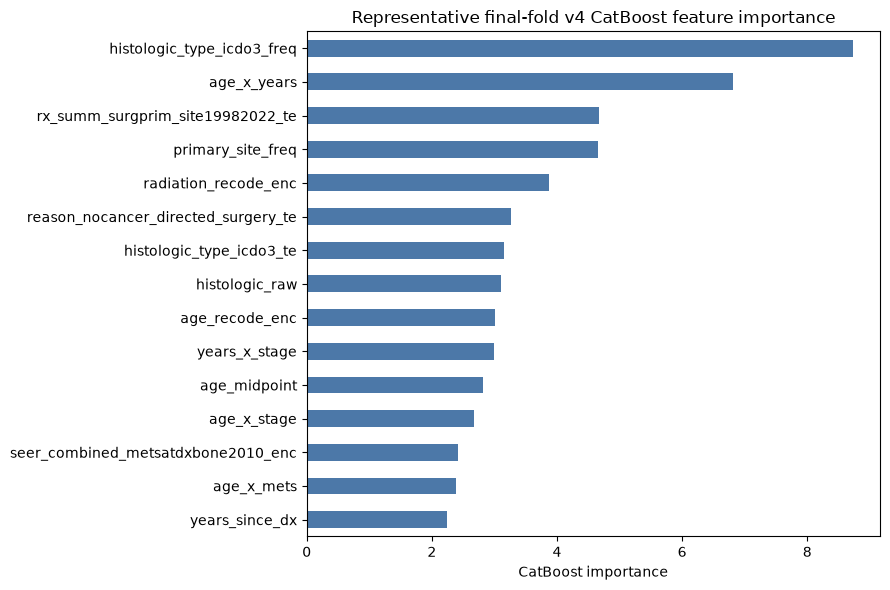

,feature,importance
0,histologic_type_icdo3_freq,8.726088
1,age_x_years,6.817150
2,rx_summ_surgprim_site19982022_te,4.676915
3,primary_site_freq,4.654092
4,radiation_recode_enc,3.879040
5,reason_nocancer_directed_surgery_te,3.257071
6,histologic_type_icdo3_te,3.156713
7,histologic_raw,3.103139
8,age_recode_enc,3.012093
9,years_x_stage,2.993897


In [6]:
representative_feature_names = list(X_train_base.columns) + [
    f"{column}_te" for column in te_cols
]

if hasattr(m, "get_feature_importance"):
    representative_importance = np.asarray(m.get_feature_importance(), dtype=float)
    if len(representative_importance) == len(representative_feature_names):
        importance_table = (
            pd.DataFrame({
                "feature": representative_feature_names,
                "importance": representative_importance,
            })
            .sort_values("importance", ascending=False)
            .head(15)
            .sort_values("importance")
        )
        ax = importance_table.plot.barh(
            x="feature",
            y="importance",
            figsize=(9, 6),
            legend=False,
            color="#4C78A8",
        )
        ax.set_title("Representative final-fold v4 CatBoost feature importance")
        ax.set_xlabel("CatBoost importance")
        ax.set_ylabel("")
        plt.tight_layout()
        plt.show()
        display(importance_table.sort_values(
            "importance", ascending=False
        ).reset_index(drop=True))
    else:
        warnings.warn("Representative importance length did not match feature names.")
else:
    warnings.warn("The retained component did not expose CatBoost importance.")


### Validation record and subgroup context

Historical saved-OOF screening favored the 80/20 blend over the pure tree
candidate, but those tree and NN vectors used different cross-validation
schemes and are not an end-to-end nested estimate. Submission 10 scored
`0.876616` on the Public Leaderboard, below Submission 6 (`0.877258`) and
Submission 12 (`0.877460`). The planned Submission 10 selection is therefore a
private-split diversity decision, not a claim that Public score proved it best.

The leakage-safe Submission 6 reconstruction found an age-55–59 weighted-F1
trough (`0.8381`) and a weak localized-stage slice. Dedicated follow-ups found
no sufficiently stable targeted fix; the NN blend is global and is not claimed
to resolve either subgroup uniformly.

### Results and limitations

The fresh output is the result of complete model fitting from the organizer
tables. The historical replay, when available, is a provenance demonstration
from preserved probability artifacts and must not be confused with retraining.
The original NN checkpoints and a contemporaneous environment manifest were
not preserved, so an exact historical neural-network retrain cannot be claimed.

The audited clean-kernel run completed in `516.84` seconds (about 8 minutes
37 seconds). Its fresh tree probability matched the historical tree bytes, but
the deterministic fresh NN did not: the final fresh blend differed from
historical Submission 10 on 108 rows and had SHA-256
`d624009d5e12e58c157bee34b664ebaf23eba05f9613f2c5e7ccd0c65a98cf34`.
The separately named historical replay matched the scored Submission 10 hash
`333af97cfbc16ffdcc2d9f910000664c443694239c60e67d6504af18687e86f1`.
This proves artifact provenance but does not close the historical NN-retrain
gap.

CPU deterministic controls and newly saved checkpoints make this fresh rerun
repeatable going forward, but numerical identity can still depend on the
supported platform and package builds. Pseudo-labeling can reinforce confident
teacher errors, and the fixed class-count rule may transfer imperfectly if
hidden prevalence differs. Neither Public LB nor saved-OOF screening reveals
the hidden Private ordering.

The workflow uses manually specified preprocessing, features, models, folds,
and ensemble weights. It uses no AutoML pipeline generator, external data,
manual test-set labels, or row-level leaderboard probing. Written organizer
clarification remains advisable for pseudo-labeling and for using historical
artifact replay as evidence of the exact scored file.
